In [2]:
from pathlib import Path
import re
import math

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from skimage.feature import hog

In [3]:
#set the processed image folder 
# Current project directory
PROJECT_DIR = Path.cwd()

# Folder containing the preprocessed 28×28 images
PROCESSED_DIR = PROJECT_DIR / "Preprocessed images"

# Folder where CSV datasets will be saved
CSV_DIR = PROJECT_DIR / "feature_csv"

# Create CSV output folder
CSV_DIR.mkdir(parents=True, exist_ok=True)

print("Project folder:")
print(PROJECT_DIR)

print("\nProcessed image folder:")
print(PROCESSED_DIR)

print("\nCSV output folder:")
print(CSV_DIR)

if not PROCESSED_DIR.exists():
    raise FileNotFoundError(
        f"Processed image folder was not found:\n{PROCESSED_DIR}"
    )

if not PROCESSED_DIR.is_dir():
    raise NotADirectoryError(
        f"The given path is not a folder:\n{PROCESSED_DIR}"
    )

print("Processed image folder found successfully.")

Project folder:
c:\Users\Asus\OneDrive\Desktop\IPPR PRoject\Final

Processed image folder:
c:\Users\Asus\OneDrive\Desktop\IPPR PRoject\Final\Preprocessed images

CSV output folder:
c:\Users\Asus\OneDrive\Desktop\IPPR PRoject\Final\feature_csv
Processed image folder found successfully.


In [ ]:

#find all processed images
IMAGE_EXTENSIONS = {
    ".png",
    ".jpg",
    ".jpeg"
   
}

processed_image_paths = [
    path
    for path in PROCESSED_DIR.rglob("*")
    if path.is_file()
    and path.suffix.lower() in IMAGE_EXTENSIONS
]

print("Total processed images found:", len(processed_image_paths))

Total processed images found: 540


In [5]:
#sort the processed images
def natural_sort_key(path):
    """
    Sorts filenames containing numbers correctly.

    Example:
    image_2.png comes before image_10.png
    """

    parts = re.split(r"(\d+)", path.name)

    return [
        int(part) if part.isdigit() else part.lower()
        for part in parts
    ]

#apply sorting 
processed_image_paths = sorted(
    processed_image_paths,
    key=natural_sort_key
)

print("First 10 processed images:")

for image_path in processed_image_paths[:10]:
    print(image_path.name)

First 10 processed images:
group_000_digit_0_index_0000.png
group_000_digit_1_index_0001.png
group_000_digit_2_index_0002.png
group_000_digit_3_index_0003.png
group_000_digit_4_index_0004.png
group_000_digit_5_index_0005.png
group_000_digit_6_index_0006.png
group_000_digit_7_index_0007.png
group_000_digit_8_index_0008.png
group_000_digit_9_index_0009.png


In [6]:
#extract labels from file name

def extract_label_from_path(image_path):
    """
    Extracts digit label from the filename or parent folder.

    Supported examples:
    group_000_digit_5_index_0005.png
    label_5_image_001.png
    class_5_image.png
    preprocessed_28x28/5/image_001.png
    """

    filename = image_path.stem.lower()

    patterns = [
        r"(?:^|[_-])digit[_-]?([0-9])(?:[_-]|$)",
        r"(?:^|[_-])label[_-]?([0-9])(?:[_-]|$)",
        r"(?:^|[_-])class[_-]?([0-9])(?:[_-]|$)"
    ]

    for pattern in patterns:

        match = re.search(pattern, filename)

        if match:
            return int(match.group(1))

    # Check whether the parent folder is named 0, 1, ..., 9
    parent_name = image_path.parent.name

    if re.fullmatch(r"[0-9]", parent_name):
        return int(parent_name)

    return None

#extract sample group

def extract_group_from_path(image_path):
    """
    Extracts sample group from filenames such as:
    group_012_digit_5_index_0125.png
    """

    match = re.search(
        r"group[_-]?(\d+)",
        image_path.stem.lower()
    )

    if match:
        return int(match.group(1))

    return None

#extract image index
def extract_index_from_path(image_path):
    """
    Extracts image index from filenames such as:
    group_000_digit_0_index_0000.png
    """

    match = re.search(
        r"index[_-]?(\d+)",
        image_path.stem.lower()
    )

    if match:
        return int(match.group(1))

    # Use the last number in the filename as fallback
    numbers = re.findall(
        r"\d+",
        image_path.stem
    )

    if numbers:
        return int(numbers[-1])

    return None


In [7]:
#create metadata fro all images

NEPALI_DIGITS = {
    0: "०",
    1: "१",
    2: "२",
    3: "३",
    4: "४",
    5: "५",
    6: "६",
    7: "७",
    8: "८",
    9: "९"
}

metadata_rows = []

for sorted_position, image_path in enumerate(processed_image_paths):

    label = extract_label_from_path(
        image_path
    )

    sample_group = extract_group_from_path(
        image_path
    )

    image_index = extract_index_from_path(
        image_path
    )

    metadata_rows.append({
        "sorted_position": sorted_position,
        "image_index": image_index,
        "sample_group": sample_group,
        "filename": image_path.name,
        "processed_path": str(image_path),
        "label": label
    })

metadata_df = pd.DataFrame(metadata_rows)

metadata_df.head(20)

,sorted_position,image_index,sample_group,filename,processed_path,label
0,0,0,0,group_000_digit_0_index_0000.png,c:\Users\Asus\OneDrive\Desktop\IPPR PRoject\Fi...,0
1,1,1,0,group_000_digit_1_index_0001.png,c:\Users\Asus\OneDrive\Desktop\IPPR PRoject\Fi...,1
2,2,2,0,group_000_digit_2_index_0002.png,c:\Users\Asus\OneDrive\Desktop\IPPR PRoject\Fi...,2
3,3,3,0,group_000_digit_3_index_0003.png,c:\Users\Asus\OneDrive\Desktop\IPPR PRoject\Fi...,3
4,4,4,0,group_000_digit_4_index_0004.png,c:\Users\Asus\OneDrive\Desktop\IPPR PRoject\Fi...,4
5,5,5,0,group_000_digit_5_index_0005.png,c:\Users\Asus\OneDrive\Desktop\IPPR PRoject\Fi...,5
6,6,6,0,group_000_digit_6_index_0006.png,c:\Users\Asus\OneDrive\Desktop\IPPR PRoject\Fi...,6
7,7,7,0,group_000_digit_7_index_0007.png,c:\Users\Asus\OneDrive\Desktop\IPPR PRoject\Fi...,7
8,8,8,0,group_000_digit_8_index_0008.png,c:\Users\Asus\OneDrive\Desktop\IPPR PRoject\Fi...,8
9,9,9,0,group_000_digit_9_index_0009.png,c:\Users\Asus\OneDrive\Desktop\IPPR PRoject\Fi...,9


In [8]:
#handle labels when filenames do not contain labels

missing_label_count = metadata_df["label"].isna().sum()

print("Images without labels:", missing_label_count)
if metadata_df["label"].isna().all():

    if len(metadata_df) % 10 != 0:
        raise ValueError(
            "Labels could not be extracted and the total number "
            "of images is not divisible by 10."
        )

    print(
        "Labels were not found in filenames. "
        "Using sorted image sequence to assign labels."
    )

    metadata_df["label"] = (
        metadata_df["sorted_position"] % 10
    )

    metadata_df["sample_group"] = (
        metadata_df["sorted_position"] // 10
    )

    metadata_df["image_index"] = (
        metadata_df["sorted_position"]
    )

elif metadata_df["label"].isna().any():

    missing_files = metadata_df[
        metadata_df["label"].isna()
    ]["filename"].tolist()

    raise ValueError(
        "Some filenames contain labels and some do not.\n"
        f"Files without labels: {missing_files[:10]}"
    )

#converts labels to integers and add nepali labels
metadata_df["label"] = (
    metadata_df["label"].astype(int)
)

metadata_df["nepali_label"] = (
    metadata_df["label"].map(NEPALI_DIGITS)
)

metadata_df.head(20)

Images without labels: 0


,sorted_position,image_index,sample_group,filename,processed_path,label,nepali_label
0,0,0,0,group_000_digit_0_index_0000.png,c:\Users\Asus\OneDrive\Desktop\IPPR PRoject\Fi...,0,०
1,1,1,0,group_000_digit_1_index_0001.png,c:\Users\Asus\OneDrive\Desktop\IPPR PRoject\Fi...,1,१
2,2,2,0,group_000_digit_2_index_0002.png,c:\Users\Asus\OneDrive\Desktop\IPPR PRoject\Fi...,2,२
3,3,3,0,group_000_digit_3_index_0003.png,c:\Users\Asus\OneDrive\Desktop\IPPR PRoject\Fi...,3,३
4,4,4,0,group_000_digit_4_index_0004.png,c:\Users\Asus\OneDrive\Desktop\IPPR PRoject\Fi...,4,४
5,5,5,0,group_000_digit_5_index_0005.png,c:\Users\Asus\OneDrive\Desktop\IPPR PRoject\Fi...,5,५
6,6,6,0,group_000_digit_6_index_0006.png,c:\Users\Asus\OneDrive\Desktop\IPPR PRoject\Fi...,6,६
7,7,7,0,group_000_digit_7_index_0007.png,c:\Users\Asus\OneDrive\Desktop\IPPR PRoject\Fi...,7,७
8,8,8,0,group_000_digit_8_index_0008.png,c:\Users\Asus\OneDrive\Desktop\IPPR PRoject\Fi...,8,८
9,9,9,0,group_000_digit_9_index_0009.png,c:\Users\Asus\OneDrive\Desktop\IPPR PRoject\Fi...,9,९


In [9]:
#check class distribution
class_distribution = (
    metadata_df
    .groupby(["label", "nepali_label"])
    .size()
    .reset_index(name="image_count")
)

class_distribution

print("Total images:", len(metadata_df))
print("Total digit classes:", metadata_df["label"].nunique())
print("Total sample groups:", metadata_df["sample_group"].nunique())


Total images: 540
Total digit classes: 10
Total sample groups: 54


Sample image shape: (28, 28)
Sample image label: 0


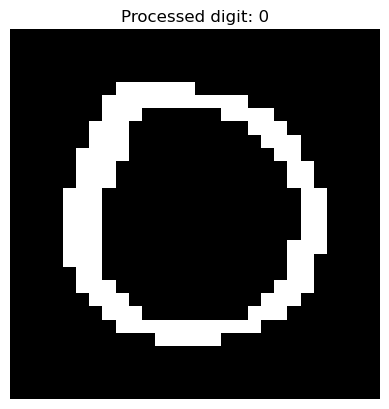

In [11]:
# read processed image

def read_processed_image(image_path):
    """
    Reads an already-preprocessed image.

    The returned image:
    - has size 28×28
    - contains a white digit
    - contains a black background
    """

    image = cv2.imread(
        str(image_path),
        cv2.IMREAD_GRAYSCALE
    )

    if image is None:
        raise ValueError(
            f"Could not read image:\n{image_path}"
        )

    # Ensure image size is 28×28
    if image.shape != (28, 28):

        image = cv2.resize(
            image,
            (28, 28),
            interpolation=cv2.INTER_AREA
        )

    # Convert image into binary form
    _, binary_image = cv2.threshold(
        image,
        127,
        255,
        cv2.THRESH_BINARY
    )

    # Detect whether the background is white
    white_pixel_ratio = (
        np.count_nonzero(binary_image) /
        binary_image.size
    )

    # White background usually covers most of the image
    if white_pixel_ratio > 0.50:
        binary_image = cv2.bitwise_not(
            binary_image
        )

    return binary_image

    #test one image 
sample_path = metadata_df.loc[
    0,
    "processed_path"
]

sample_image = read_processed_image(sample_path)

print("Sample image shape:", sample_image.shape)
print("Sample image label:", metadata_df.loc[0, "label"])

plt.imshow(sample_image, cmap="gray")
plt.title(
    f"Processed digit: {metadata_df.loc[0, 'label']}"
)
plt.axis("off")
plt.show()

C:\Users\Asus\AppData\Local\Temp\ipykernel_2468\2227470712.py:28: UserWarning: Glyph 2406 (\N{DEVANAGARI DIGIT ZERO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Asus\AppData\Local\Temp\ipykernel_2468\2227470712.py:28: UserWarning: Matplotlib currently does not support Devanagari natively.
  plt.tight_layout()
C:\Users\Asus\AppData\Local\Temp\ipykernel_2468\2227470712.py:28: UserWarning: Glyph 2407 (\N{DEVANAGARI DIGIT ONE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Asus\AppData\Local\Temp\ipykernel_2468\2227470712.py:28: UserWarning: Glyph 2408 (\N{DEVANAGARI DIGIT TWO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Asus\AppData\Local\Temp\ipykernel_2468\2227470712.py:28: UserWarning: Glyph 2409 (\N{DEVANAGARI DIGIT THREE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Asus\AppData\Local\Temp\ipykernel_2468\2227470712.py:28: UserWarning: Glyph 2410 (\N{DEVANAGARI DIGIT FOUR}) missing from font(s) DejaVu Sans

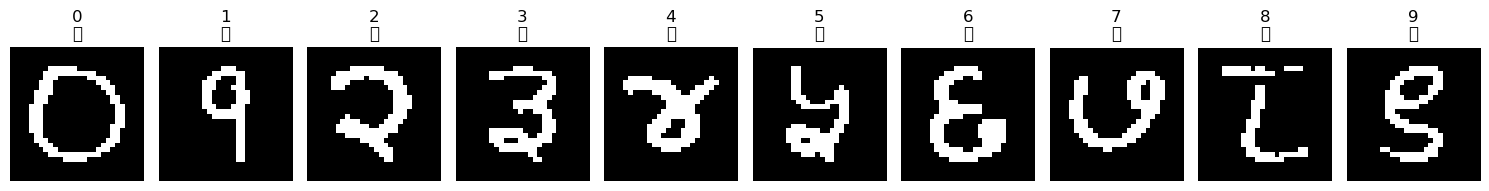

In [12]:
#display sample images from all classes
plt.figure(figsize=(15, 4))

for label in range(10):

    class_rows = metadata_df[
        metadata_df["label"] == label
    ]

    if len(class_rows) == 0:
        continue

    image_path = class_rows.iloc[0][
        "processed_path"
    ]

    image = read_processed_image(
        image_path
    )

    plt.subplot(1, 10, label + 1)
    plt.imshow(image, cmap="gray")
    plt.title(
        f"{label}\n{NEPALI_DIGITS[label]}"
    )
    plt.axis("off")

plt.tight_layout()
plt.show()

In [13]:
#extract basic shape features
def extract_basic_features(processed_image):
    """
    Extracts basic statistical, contour, shape,
    symmetry and transition features.
    """

    binary = (
        processed_image > 0
    ).astype(np.uint8)

    image_height, image_width = binary.shape

    foreground_y, foreground_x = np.where(
        binary > 0
    )

    if len(foreground_x) == 0:

        return {
            "foreground_pixels": 0,
            "foreground_ratio": 0.0,
            "bbox_width": 0,
            "bbox_height": 0,
            "aspect_ratio": 0.0,
            "bbox_density": 0.0,
            "centroid_x": 0.0,
            "centroid_y": 0.0,
            "contour_area": 0.0,
            "perimeter": 0.0,
            "solidity": 0.0,
            "compactness": 0.0,
            "orientation": 0.0,
            "eccentricity": 0.0,
            "number_of_holes": 0,
            "horizontal_symmetry": 0.0,
            "vertical_symmetry": 0.0,
            "horizontal_transition_rate": 0.0,
            "vertical_transition_rate": 0.0
        }

    # Foreground features
    foreground_pixels = int(
        binary.sum()
    )

    foreground_ratio = float(
        foreground_pixels / binary.size
    )

    # Bounding-box features
    minimum_x = int(foreground_x.min())
    maximum_x = int(foreground_x.max())
    minimum_y = int(foreground_y.min())
    maximum_y = int(foreground_y.max())

    bbox_width = (
        maximum_x - minimum_x + 1
    )

    bbox_height = (
        maximum_y - minimum_y + 1
    )

    aspect_ratio = (
        bbox_width / bbox_height
        if bbox_height > 0
        else 0.0
    )

    bbox_area = bbox_width * bbox_height

    bbox_density = (
        foreground_pixels / bbox_area
        if bbox_area > 0
        else 0.0
    )

    # Normalized centroid
    centroid_x = float(
        foreground_x.mean() / image_width
    )

    centroid_y = float(
        foreground_y.mean() / image_height
    )

    # Contour features
    contour_image = (
        binary * 255
    ).astype(np.uint8)

    contours, hierarchy = cv2.findContours(
        contour_image,
        cv2.RETR_CCOMP,
        cv2.CHAIN_APPROX_SIMPLE
    )

    contour_area = 0.0
    perimeter = 0.0
    solidity = 0.0
    compactness = 0.0
    number_of_holes = 0

    if contours:

        largest_contour = max(
            contours,
            key=cv2.contourArea
        )

        contour_area = float(
            cv2.contourArea(largest_contour)
        )

        perimeter = float(
            cv2.arcLength(
                largest_contour,
                True
            )
        )

        convex_hull = cv2.convexHull(
            largest_contour
        )

        convex_hull_area = float(
            cv2.contourArea(convex_hull)
        )

        if convex_hull_area > 0:
            solidity = (
                contour_area /
                convex_hull_area
            )

        if perimeter > 0:
            compactness = (
                4 * math.pi * contour_area /
                (perimeter ** 2)
            )

        if hierarchy is not None:

            hierarchy_data = hierarchy[0]

            number_of_holes = int(
                np.sum(
                    hierarchy_data[:, 3] >= 0
                )
            )

    # Orientation and eccentricity
    coordinates = np.column_stack(
        (foreground_x, foreground_y)
    ).astype(np.float64)

    orientation = 0.0
    eccentricity = 0.0

    if len(coordinates) > 1:

        covariance_matrix = np.cov(
            coordinates,
            rowvar=False
        )

        covariance_xx = covariance_matrix[0, 0]
        covariance_yy = covariance_matrix[1, 1]
        covariance_xy = covariance_matrix[0, 1]

        orientation = float(
            0.5 * math.atan2(
                2 * covariance_xy,
                covariance_xx - covariance_yy
            )
        )

        eigenvalues = np.linalg.eigvalsh(
            covariance_matrix
        )

        eigenvalues = np.sort(
            eigenvalues
        )[::-1]

        if eigenvalues[0] > 0:

            eccentricity = float(
                math.sqrt(
                    max(
                        0.0,
                        1.0 -
                        eigenvalues[1] /
                        eigenvalues[0]
                    )
                )
            )

    # Symmetry features
    left_right_flipped = np.fliplr(
        binary
    )

    top_bottom_flipped = np.flipud(
        binary
    )

    horizontal_symmetry = float(
        1.0 -
        np.mean(
            np.abs(
                binary.astype(float) -
                left_right_flipped.astype(float)
            )
        )
    )

    vertical_symmetry = float(
        1.0 -
        np.mean(
            np.abs(
                binary.astype(float) -
                top_bottom_flipped.astype(float)
            )
        )
    )

    # Stroke transition features
    horizontal_transitions = np.abs(
        np.diff(
            binary.astype(np.int16),
            axis=1
        )
    )

    vertical_transitions = np.abs(
        np.diff(
            binary.astype(np.int16),
            axis=0
        )
    )

    horizontal_transition_rate = float(
        horizontal_transitions.mean()
    )

    vertical_transition_rate = float(
        vertical_transitions.mean()
    )

    return {
        "foreground_pixels": foreground_pixels,
        "foreground_ratio": foreground_ratio,
        "bbox_width": bbox_width,
        "bbox_height": bbox_height,
        "aspect_ratio": aspect_ratio,
        "bbox_density": bbox_density,
        "centroid_x": centroid_x,
        "centroid_y": centroid_y,
        "contour_area": contour_area,
        "perimeter": perimeter,
        "solidity": solidity,
        "compactness": compactness,
        "orientation": orientation,
        "eccentricity": eccentricity,
        "number_of_holes": number_of_holes,
        "horizontal_symmetry": horizontal_symmetry,
        "vertical_symmetry": vertical_symmetry,
        "horizontal_transition_rate": horizontal_transition_rate,
        "vertical_transition_rate": vertical_transition_rate
    }


In [16]:
#extract HOG features 
def extract_hog_features(processed_image):
    """
    Extracts 324 HOG features from a processed digit image.
    """

    # HOG works conveniently with a 32×32 image
    hog_image = cv2.resize(
        processed_image,
        (32, 32),
        interpolation=cv2.INTER_AREA
    )

    hog_image = (
        hog_image.astype(np.float32) /
        255.0
    )

    hog_vector = hog(
        hog_image,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        block_norm="L2-Hys",
        feature_vector=True
    )

    hog_features = {
        f"hog_{index:03d}": float(value)
        for index, value in enumerate(hog_vector)
    }

    return hog_features

In [17]:
sample_hog_features = extract_hog_features(
    sample_image
)

print(
    "Number of HOG features:",
    len(sample_hog_features)
)

Number of HOG features: 324


In [23]:
#extract features from all processed images
basic_rows = []
hog_rows = []
combined_rows = []
pixel_rows = []

total_images = len(metadata_df)

for row_number, row in metadata_df.iterrows():

    processed_image = read_processed_image(
        row["processed_path"]
    )

    metadata = {
        "image_index": row["image_index"],
        "sample_group": row["sample_group"],
        "filename": row["filename"],
        "label": row["label"],
        "nepali_label": row["nepali_label"]
    }

    # basic features
    basic_features = (
        extract_basic_features(
            processed_image
        )
    )

    basic_rows.append({
        **metadata,
        **basic_features
    })

    # HOG features
    hog_features = extract_hog_features(
        processed_image
    )

    hog_rows.append({
        **metadata,
        **hog_features
    })

    # Combined handcrafted and HOG
    combined_rows.append({
        **metadata,
        **basic_features,
        **hog_features
    })

    # Raw 28×28 pixel features
    normalized_pixels = (
        processed_image.flatten().astype(np.float32) /
        255.0
    )

    pixel_features = {
        f"pixel_{pixel_index:03d}": float(pixel_value)
        for pixel_index, pixel_value
        in enumerate(normalized_pixels)
    }

    pixel_rows.append({
        **metadata,
        **pixel_features
    })

    if (row_number + 1) % 50 == 0:

        print(
            f"Extracted features from "
            f"{row_number + 1}/{total_images} images"
        )

print("Feature extraction completed successfully.")

Extracted features from 50/540 images
Extracted features from 100/540 images
Extracted features from 150/540 images
Extracted features from 200/540 images
Extracted features from 250/540 images
Extracted features from 300/540 images
Extracted features from 350/540 images
Extracted features from 400/540 images
Extracted features from 450/540 images
Extracted features from 500/540 images
Feature extraction completed successfully.


In [30]:
#convet extracted featues into dataframes
basic_features_df = pd.DataFrame(
    basic_rows
)

hog_df = pd.DataFrame(
    hog_rows
)

combined_df = pd.DataFrame(
    combined_rows
)

pixel_df = pd.DataFrame(
    pixel_rows
)

In [32]:
#check shapes
print(
    "Basic dataset shape:",
     basic_features_df.shape
)

print(
    "HOG dataset shape:",
    hog_df.shape
)

print(
    "Combined dataset shape:",
    combined_df.shape
)

print(
    "Pixel dataset shape:",
    pixel_df.shape
)

Basic dataset shape: (540, 24)
HOG dataset shape: (540, 329)
Combined dataset shape: (540, 348)
Pixel dataset shape: (540, 789)


In [34]:
#display extracted feature data
basic_features_df.head()

,image_index,sample_group,filename,label,nepali_label,foreground_pixels,foreground_ratio,bbox_width,bbox_height,aspect_ratio,...,perimeter,solidity,compactness,orientation,eccentricity,number_of_holes,horizontal_symmetry,vertical_symmetry,horizontal_transition_rate,vertical_transition_rate
0,0,0,group_000_digit_0_index_0000.png,0,०,121,0.154337,20,20,1.00,...,64.284271,0.969492,0.869694,0.438124,0.392194,1,0.936224,0.936224,0.095238,0.092593
1,1,0,group_000_digit_1_index_0001.png,1,१,80,0.102041,10,20,0.50,...,50.727922,0.710638,0.407758,1.305890,0.862139,1,0.923469,0.913265,0.071429,0.042328
2,2,0,group_000_digit_2_index_0002.png,2,२,131,0.167092,17,20,0.85,...,89.497474,0.406593,0.145121,1.393892,0.629854,0,0.834184,0.742347,0.068783,0.082011
3,3,0,group_000_digit_3_index_0003.png,3,३,116,0.147959,14,20,0.70,...,96.426406,0.347032,0.102714,-1.405553,0.760773,1,0.867347,0.775510,0.066138,0.100529
4,4,0,group_000_digit_4_index_0004.png,4,४,135,0.172194,20,16,1.25,...,70.426406,0.575610,0.298965,1.013011,0.502220,1,0.859694,0.823980,0.066138,0.079365


In [35]:
#display some hog values
hog_df[
    [
        "filename",
        "label",
        "hog_000",
        "hog_001",
        "hog_002",
        "hog_003",
        "hog_004"
    ]
].head()

,filename,label,hog_000,hog_001,hog_002,hog_003,hog_004
0,group_000_digit_0_index_0000.png,0,0.097535,0.0,0.107236,0.000000,0.010705
1,group_000_digit_1_index_0001.png,1,0.000000,0.0,0.000000,0.000000,0.000000
2,group_000_digit_2_index_0002.png,2,0.134676,0.0,0.368511,0.102339,0.032338
3,group_000_digit_3_index_0003.png,3,0.266293,0.0,0.000000,0.000000,0.000000
4,group_000_digit_4_index_0004.png,4,0.003623,0.0,0.278850,0.029493,0.294343


In [ ]:

#check invalid and missing values
print(
    "Missing values in basic dataset:",
    basic_features_df.isnull().sum().sum()
)

print(
    "Missing values in HOG dataset:",
    hog_df.isnull().sum().sum()
)

print(
    "Missing values in combined dataset:",
    combined_df.isnull().sum().sum()
)



Missing values in basic dataset: 0
Missing values in HOG dataset: 0
Missing values in combined dataset: 0
Missing values in pixel dataset: 0


In [37]:
#replace missing and infinite values
basic_features_df = basic_features_df.replace(
    [np.inf, -np.inf],
    0
).fillna(0)

hog_df = hog_df.replace(
    [np.inf, -np.inf],
    0
).fillna(0)

combined_df = combined_df.replace(
    [np.inf, -np.inf],
    0
).fillna(0)

pixel_df = pixel_df.replace(
    [np.inf, -np.inf],
    0
).fillna(0)

print("Invalid values handled successfully.")

Invalid values handled successfully.


In [41]:
from pathlib import Path

PROJECT_DIR = Path.cwd()
CSV_DIR = PROJECT_DIR / "feature_csv"

CSV_DIR.mkdir(parents=True, exist_ok=True)

BASIC_CSV = CSV_DIR / "nepali_digit_basic_features.csv"
HOG_CSV = CSV_DIR / "nepali_digit_hog_features.csv"
COMBINED_CSV = CSV_DIR / "nepali_digit_basic_hog_combined_features.csv"
PIXEL_CSV = CSV_DIR / "nepali_digit_pixels_28x28.csv"

print("CSV paths created successfully.")

CSV paths created successfully.


In [ ]:
#save the csv fles
basic_features_df.to_csv(
    BASIC_CSV,
    index=False
)

hog_df.to_csv(
    HOG_CSV,
    index=False
)

combined_df.to_csv(
    COMBINED_CSV,
    index=False
)

pixel_df.to_csv(
    PIXEL_CSV,
    index=False
)

print("CSV datasets created successfully.")

print("\nBasic Features:")
print(BASIC_CSV)

print("\nHOG features:")
print(HOG_CSV)

print("\nCombined features:")
print(COMBINED_CSV)


CSV datasets created successfully.

Basic Features:
c:\Users\Asus\OneDrive\Desktop\IPPR PRoject\Final\feature_csv\nepali_digit_basic_features.csv

HOG features:
c:\Users\Asus\OneDrive\Desktop\IPPR PRoject\Final\feature_csv\nepali_digit_hog_features.csv

Combined features:
c:\Users\Asus\OneDrive\Desktop\IPPR PRoject\Final\feature_csv\nepali_digit_basic_hog_combined_features.csv

Raw pixel features:
c:\Users\Asus\OneDrive\Desktop\IPPR PRoject\Final\feature_csv\nepali_digit_pixels_28x28.csv
